In [46]:
import pandas as pd

In [47]:
df = pd.read_excel("metrics.xlsx","Sheet2")
print(df)

    # threads # chunk  static -O3  dynamic -O3  guided -O3
0          40       -     7.32416      7.79796     7.44455
1          40       -     8.32223      7.86867     8.10656
2          40       -    10.31410      9.13520     8.64417
3          20       -     9.49860      7.97679     7.07664
4          20       -    10.52080      9.00685     8.77442
5          20       -    11.70780      9.89775    10.94660
6          12       -     9.45145      6.38480     7.80763
7          12       -    10.52770      6.42904     8.42492
8          12       -    12.94420      6.74784     9.56208
9           6       -    15.81260     10.38720    11.31770
10          6       -    16.86050     11.31950    12.30140
11          6       -    17.13120     11.49010    12.53570
12          3       -    26.82890     16.99190    18.97200
13          3       -    28.25050     16.99140    19.52420
14          3       -    27.86970     16.96740    19.51010
15          1       -    38.64390     39.14820    38.045

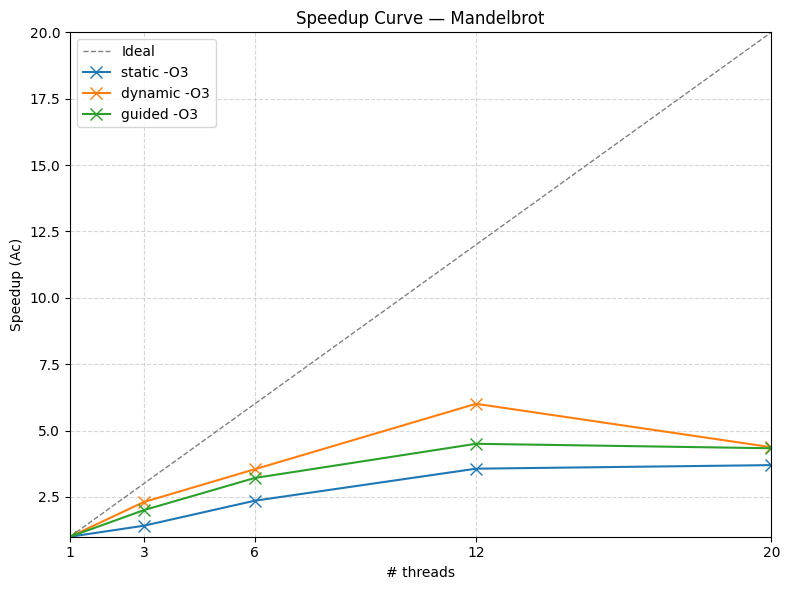

In [48]:
import matplotlib.pyplot as plt

skip_threads = [40]

# Mean per thread count
means = df.groupby("# threads")[["static -O3", "dynamic -O3", "guided -O3"]].mean().sort_index()
means = means.drop(index=skip_threads, errors='ignore')

# Ts = T1 (mean execution time with 1 thread)
Ts = means.loc[1]

# Ac = Ts / Tp
ac = Ts / means

threads = means.index.tolist()
schedules = ["static -O3", "dynamic -O3", "guided -O3"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(8, 6))

# Ideal speedup line (1:1 reference)
ax.plot(threads, threads, linestyle='--', color='gray', linewidth=1, label='Ideal')

for sched, color in zip(schedules, colors):
    ax.plot(threads, ac[sched], marker='x', color=color, markersize=8, linewidth=1.5, label=sched)

ax.set_xlabel("# threads")
ax.set_ylabel("Speedup (Ac)")
ax.set_title("Speedup Curve — Mandelbrot")
ax.set_xticks(threads)
ax.set_xlim(1, threads[-1])
ax.set_ylim(1, threads[-1])
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df_chunk = pd.read_excel("metrics.xlsx", "Sheet3")

cols = ["static -O3", "dynamic -O3", "guided -O3"]
df_chunk[cols] = df_chunk[cols].apply(pd.to_numeric, errors='coerce')

print(df_chunk)
print(df_chunk.dtypes)


    # threads  # chunk  static -O3  dynamic -O3  guided -O3
0           1        1     37.0689      38.7876     37.0391
1           1        1     38.1234      39.8239     38.0098
2           1        1     38.2266      39.8469     38.1461
3           1        5     38.3270      39.9160     38.1611
4           1        5     38.4548      39.7664     38.3642
..        ...      ...         ...          ...         ...
79         12     8000     40.3489      42.2261     39.1762
80         12     8000     40.9180      39.9644     38.8871
81         12    16000     40.3959      39.9624     38.9828
82         12    16000     39.9073      41.0744     39.1078
83         12    16000     39.8806      39.8663     38.4978

[84 rows x 5 columns]
# threads        int64
# chunk          int64
static -O3     float64
dynamic -O3    float64
guided -O3     float64
dtype: object


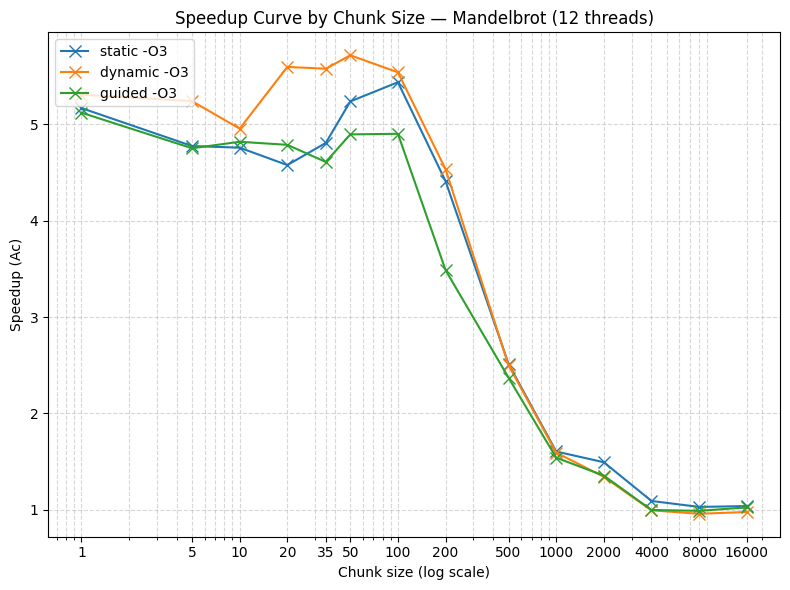

In [50]:
import matplotlib.pyplot as plt

cols = ["static -O3", "dynamic -O3", "guided -O3"]

# Ts = mean time with 1 thread, per chunk size
ts_per_chunk = df_chunk[df_chunk["# threads"] == 1].groupby("# chunk")[cols].mean().sort_index()

# Tp = mean time with 12 threads, per chunk size
tp_per_chunk = df_chunk[df_chunk["# threads"] == 12].groupby("# chunk")[cols].mean().sort_index()

# Ac = Ts / Tp per chunk
ac_chunk = ts_per_chunk / tp_per_chunk

chunks = ac_chunk.index.tolist()
schedules = ["static -O3", "dynamic -O3", "guided -O3"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(8, 6))

for sched, color in zip(schedules, colors):
    ax.plot(chunks, ac_chunk[sched], marker='x', color=color, markersize=8, linewidth=1.5, label=sched)

ax.set_xscale('log')
ax.set_xlabel("Chunk size (log scale)")
ax.set_ylabel("Speedup (Ac)")
ax.set_title("Speedup Curve by Chunk Size — Mandelbrot (12 threads)")
ax.set_xticks(chunks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5, which='both')

plt.tight_layout()
plt.show()
